In [41]:
import numpy as np
import torch
import pandas as pd

### get pto/pno results

In [42]:
mse_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/timed_logs/knapsack-energy/mse/visual/2024-06-03 10-07-27.039392/"
spo_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/timed_logs/knapsack-energy/spo/visual/2024-06-03 10-41-21.266640/"

In [43]:
def read_preds(log_dir):
    return torch.load(log_dir + "/tensors/preds.pt")

In [44]:
mse_preds = read_preds(mse_dir)
spo_preds = read_preds(spo_dir)


In [45]:
mse_preds.shape

torch.Size([237, 48, 1])

### get raw data

In [46]:
fname = "/home/genghaoyu/OR/PTO/Rethink1.0/openpto/data/energy/prices2013.dat"
def get_energy( fname=None, trainTestRatio=0.70):
    df = get_energy_pandas(fname)

    length = df["groupID"].nunique()
    grouplength = 48

    # numpy arrays, X contains groupID as first column
    X1g = df.loc[:, df.columns != "SMPEP2"].values
    y = df.loc[:, "SMPEP2"].values

    # no negative values allowed...for now I just clamp these values to zero. They occur three times in the training data.
    # for i in range(len(y)):
    #     y[i] = max(y[i], 0)

    # ordered split per complete group
    train_len = int(trainTestRatio * length)

    # the splitting
    X_1gtrain = X1g[: grouplength * train_len]
    y_train = y[: grouplength * train_len]
    X_1gtest = X1g[grouplength * train_len :]
    y_test = y[grouplength * train_len :]
    return (X_1gtrain, y_train, X_1gtest, y_test)

def get_energy_pandas(fname=None):
    if fname is None:
        fname = "prices2013.dat"

    df = pd.read_csv(fname, delim_whitespace=True, quotechar='"')
    # remove unnecessary columns
    df.drop(
        ["#DateTime", "Holiday", "ActualWindProduction", "SystemLoadEP2"],
        axis=1,
        inplace=True,
    )
    # remove columns with missing values
    df.drop(["ORKTemperature", "ORKWindspeed"], axis=1, inplace=True)

    # missing value treatment
    # df[pd.isnull(df).any(axis=1)]
    # impute missing CO2 intensities linearly
    df.loc[df.loc[:, "CO2Intensity"] == 0, "CO2Intensity"] = np.nan  # an odity
    df.loc[:, "CO2Intensity"].interpolate(inplace=True)
    # remove remaining 3 days with missing values
    grouplength = 48
    for i in range(0, len(df), grouplength):
        day_has_nan = pd.isnull(df.loc[i : i + (grouplength - 1)]).any(axis=1).any()
        if day_has_nan:
            # print("Dropping",i)
            df.drop(range(i, i + grouplength), inplace=True)
    # data is sorted by year, month, day, periodofday; don't want learning over this
    df.drop(["Day", "Year", "PeriodOfDay"], axis=1, inplace=True)

    # insert group identifier at beginning
    grouplength = 48
    length = int(len(df) / 48)  # 792
    gids = [gid for gid in range(length) for i in range(grouplength)]
    df.insert(0, "groupID", gids)
    return df

X_train, y_train, X_test, y_test = get_energy(fname=fname)

In [47]:
y_test = y_test.reshape(-1, 48, 1)
y_test.shape

(237, 48, 1)

### visual

In [48]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
# 设置
pd.options.display.notebook_repr_html=False  # 表格显示
plt.rcParams['figure.dpi'] = 75  # 图形分辨率
sns.set_theme(style='darkgrid')  # 图形主题

In [52]:
ins_id = 200
df_pred = pd.DataFrame(
     {
    "Time": np.arange(48)/2,
    "Real": y_test[ins_id, :, 0],
    "PtO(MSE)" : mse_preds[ins_id, :, 0],
    "PnO(SPO)" : spo_preds[ins_id, :, 0],
    }
)
 
df_pred

    Time    Real    PtO(MSE)    PnO(SPO)
0    0.0   55.05   69.137726   62.800865
1    0.5   55.05   66.852768   60.402065
2    1.0   55.05   66.322029   59.356380
3    1.5   55.05   66.598442   59.464088
4    2.0   55.05   62.163532   53.369495
5    2.5   55.05   61.218338   51.697479
6    3.0   55.05   61.225346   51.216530
7    3.5   55.05   63.899239   53.800983
8    4.0   47.51   60.917168   50.264503
9    4.5   47.51   60.879601   50.295223
10   5.0   55.05   64.919563   54.769394
11   5.5   56.88   66.244965   58.101364
12   6.0   50.98   64.027481   58.811474
13   6.5   54.13   65.770706   62.732384
14   7.0   60.28   67.663643   66.086845
15   7.5   61.43   76.138412   73.644508
16   8.0   60.28   80.373756   78.156990
17   8.5   60.28   80.971123   78.490730
18   9.0   60.28   81.852310   79.719147
19   9.5   60.28   86.173119   83.320541
20  10.0   60.28   86.226265   83.430519
21  10.5   60.28   87.077446   83.904480
22  11.0   60.28   87.161049   83.927292
23  11.5   60.28

/tmp/ipykernel_3198/616033826.py:9: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(x = "Time", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred, ["Time"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


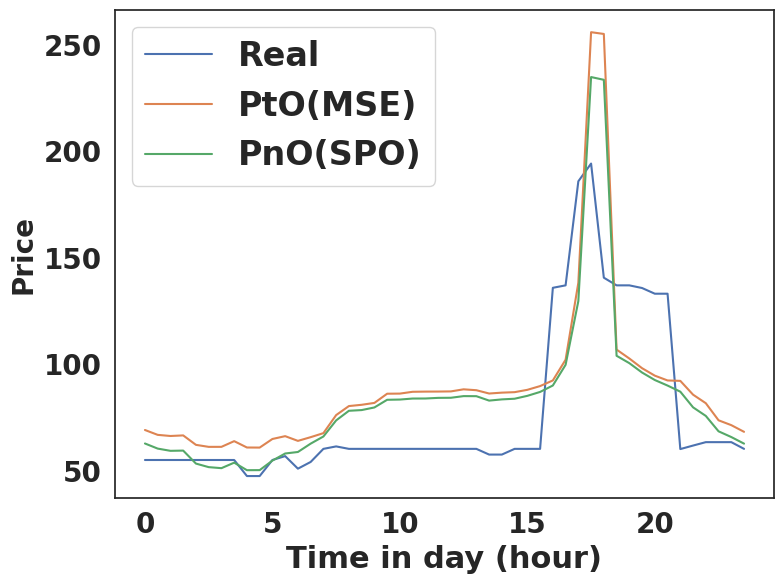

In [66]:
palette = sns.color_palette("deep")
sns.set_style("white")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure(dpi=100, figsize=(8, 6))
metric_name="Price"
# sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss, ["Epoch"], value_name=metric_name, var_name='Method'))
sns.lineplot(x = "Time", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred, ["Time"], value_name=metric_name, var_name='Method'))

plt.xlabel('Time in day (hour)',fontsize=22,fontweight='bold') 
plt.ylabel("Price",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=20,fontweight='bold')
plt.yticks(fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 24,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/energy_pred.pdf',facecolor="w")